## Ejercicio 1: Evaluación de solicitud de crédito bancario

Este ejercicio consiste en diseñar un agente inteligente que evalúe una solicitud de crédito considerando el ingreso mensual, el monto solicitado y si el cliente presenta historial moroso.

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **P - Medida de desempeño** | Aprobar solicitudes con un nivel de riesgo aceptable y rechazar aquellas que representen un mayor riesgo para el banco. |
| **E - Entorno** | Banco, clientes y solicitudes de crédito. |
| **A - Acciones** | Aprobar, aprobar con condiciones o rechazar la solicitud. |
| **S - Percepción** | Ingreso mensual, monto solicitado e historial moroso del cliente. |
| **Objetivo** | Evaluar cada solicitud de crédito y tomar una decisión que permita reducir el riesgo para el banco. |

### Justificación de las reglas

Para evaluar las solicitudes se utiliza la relación entre el monto solicitado y el ingreso mensual. Una relación baja representa un menor riesgo para el banco, mientras que una relación alta representa un mayor riesgo. También se considera el historial moroso, ya que tener antecedentes de morosidad incrementa el riesgo de incumplimiento. Por ello, ambos factores se combinan para decidir si se aprueba, se aprueba con condiciones o se rechaza la solicitud.

#### Reglas de decisión

| Relación monto/ingreso | Sin historial moroso | Con historial moroso |
|---|---|---|
| Menor o igual a 0.30 | Aprobar | Aprobar con condiciones |
| Mayor a 0.30 y menor o igual a 0.50 | Aprobar con condiciones | Rechazar |
| Mayor a 0.50 | Rechazar | Rechazar |

### Código

A continuación se implementa el agente de crédito utilizando las reglas de decisión definidas anteriormente.

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    if relacion <= 0.30:
        if tiene_historial_moroso:
            return (
                "aprobar con condiciones",
                "relación monto/ingreso baja, pero presenta historial moroso"
            )
        else:
            return (
                "aprobar",
                "relación monto/ingreso baja y no presenta historial moroso"
            )

    elif relacion <= 0.50:
        if tiene_historial_moroso:
            return (
                "rechazar",
                "relación monto/ingreso media y presenta historial moroso"
            )
        else:
            return (
                "aprobar con condiciones",
                "relación monto/ingreso media y no presenta historial moroso"
            )

    else:
        return (
            "rechazar",
            "relación monto/ingreso alta"
        )

### Simulación y pruebas

Se realizan diferentes casos de prueba variando el ingreso mensual, el monto solicitado y el historial moroso. También se incluyen casos límite con relaciones de 0.30 y 0.50 para comprobar el comportamiento del agente en los bordes de las reglas establecidas.

In [2]:
casos_prueba = [
    (3000, 600, False),    # Relación 0.20
    (3000, 600, True),     # Relación 0.20
    (4000, 1200, False),   # Relación 0.30 - caso límite
    (4000, 1600, False),   # Relación 0.40
    (4000, 1600, True),    # Relación 0.40
    (4000, 2000, False),   # Relación 0.50 - caso límite
    (4000, 2400, False)    # Relación 0.60
]

for ingreso, monto, historial in casos_prueba:
    accion, motivo = agente_credito(ingreso, monto, historial)
    relacion = monto / ingreso

    print(f"Ingreso mensual: S/ {ingreso}")
    print(f"Monto solicitado: S/ {monto}")
    print(f"Historial moroso: {historial}")
    print(f"Relación monto/ingreso: {relacion:.2f}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 50)

Ingreso mensual: S/ 3000
Monto solicitado: S/ 600
Historial moroso: False
Relación monto/ingreso: 0.20
Decisión: aprobar
Motivo: relación monto/ingreso baja y no presenta historial moroso
--------------------------------------------------
Ingreso mensual: S/ 3000
Monto solicitado: S/ 600
Historial moroso: True
Relación monto/ingreso: 0.20
Decisión: aprobar con condiciones
Motivo: relación monto/ingreso baja, pero presenta historial moroso
--------------------------------------------------
Ingreso mensual: S/ 4000
Monto solicitado: S/ 1200
Historial moroso: False
Relación monto/ingreso: 0.30
Decisión: aprobar
Motivo: relación monto/ingreso baja y no presenta historial moroso
--------------------------------------------------
Ingreso mensual: S/ 4000
Monto solicitado: S/ 1600
Historial moroso: False
Relación monto/ingreso: 0.40
Decisión: aprobar con condiciones
Motivo: relación monto/ingreso media y no presenta historial moroso
--------------------------------------------------
Ingreso m

### Visualización

Se generan 200 solicitudes aleatorias para observar gráficamente las decisiones tomadas por el agente. En el eje X se representa la relación entre el monto solicitado y el ingreso mensual, mientras que en el eje Y se representa el ingreso mensual.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cantidad = 200

ingresos = np.random.randint(1000, 10001, cantidad)
montos = np.random.randint(200, 6001, cantidad)
historiales = np.random.choice([True, False], cantidad)

relaciones = []
decisiones = []

for ingreso, monto, historial in zip(ingresos, montos, historiales):
    relacion = monto / ingreso
    accion, motivo = agente_credito(ingreso, monto, historial)

    relaciones.append(relacion)
    decisiones.append(accion)

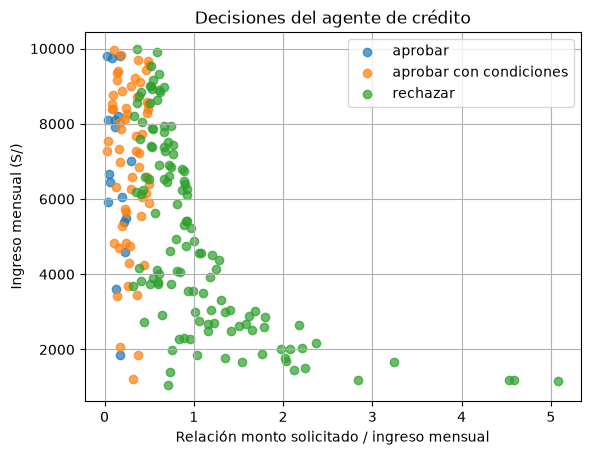

In [4]:
for decision in ["aprobar", "aprobar con condiciones", "rechazar"]:
    indices = [
        i for i, accion in enumerate(decisiones)
        if accion == decision
    ]

    plt.scatter(
        [relaciones[i] for i in indices],
        [ingresos[i] for i in indices],
        label=decision,
        alpha=0.7
    )

plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Decisiones del agente de crédito")
plt.legend()
plt.grid(True)
plt.show()